# Shape Classifier Model
<h3>By Raz Asraf - 8110, Tal Leibovitz - 0506, Adir Beitbabu - 6489</h3>


<h3>Project Overview</h3>
<p>Our machine learning model is a multiclass classification model, which when given a shape between our 8 existing shapes in our dataset, will identify the shape. The shapes that we are going to classify are: Triangle, Trapezoid, Square, Rhombus, Rectangle, Parrallelogram, Kite, Circle.</p>
<p>Our model will learn using <b>*Ann Algorithm</b>.</p>

<h3> The use of AI </h3>

<p>In order to help us we have used AI in couple of diffrent points points in our project and the promet are as such:</p>

<li>"Please explain to me what is ANN Algorithm and how does it work" - Since we haven't learned ANN in class we wanted to get a better understanding of the Algorithm so we have asked the AI about it</li>
<li>"[Giving him a paragraph] Please check our understanding and make sure the grammer is correct" - We used it espacily in the math sections in order to see that our assumptions are correct and of course make sure our work is understandable and written well</li>
<li>[Given a piece of code and a problem] please can you show me how that can be optimized\look like" - We used it to optimize and "clean" our code in order to make it more understandable and easy to explain and also used it to add more visuals and easy to understand graphs</li>  

In [1]:
import os
import copy
import random

import numpy as np
import pandas as pd
import torch
import PIL.ImageOps
from PIL import Image
from torch.utils.data import Dataset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


<h3>Dataset Loading</h3>
<p>Our dataset will be stored in a CSV file which the columns will represent</p>
<li><b>File path</b> - This column will represent the path for each picture in our dataset corresponding to where the CSV file is located.</li>
<li><b>Label</b> - This column will represent our classifiers in which each row will have 1 of our 8 shapes.</li>
<li><b>Dataset</b> - This column will represent what type of data the folder represents, train, test, or valid.</li>


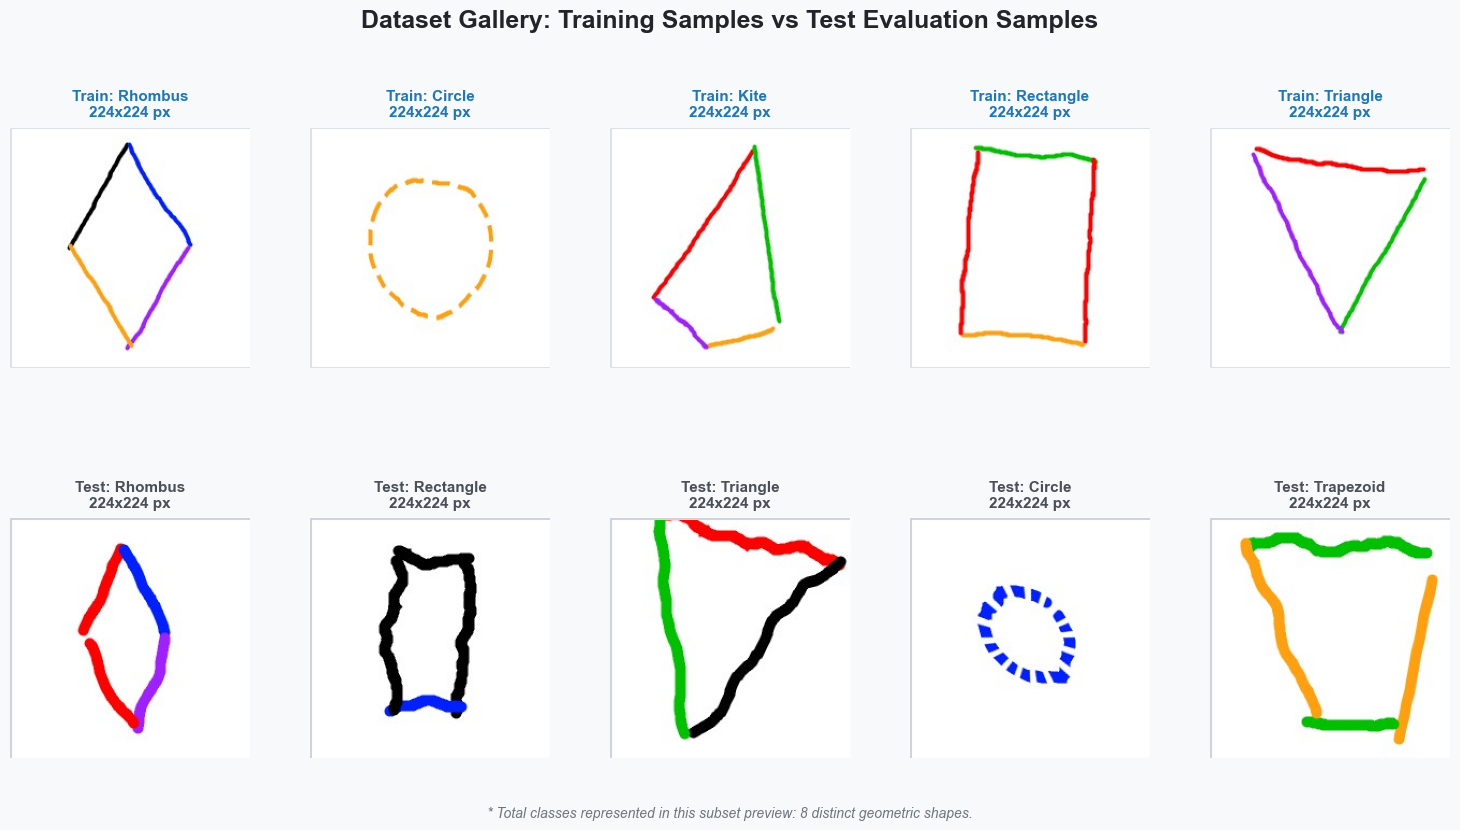

In [2]:
# הגדרת עיצוב מודרני ונקי
sns.set_theme(style="white")

# 1. טעינת הנתונים
csv_path = 'Database/shapes.csv'  # שנה ל-'Database/shapes.csv' אם הקובץ יושב שם
if not os.path.exists(csv_path):
    print(f"❌ שגיאה: לא נמצא קובץ בשם {csv_path}")
else:
    df = pd.read_csv(csv_path)

    label_col = 'labels'      
    set_col = 'data set'      
    path_col = 'filepaths'    

    # 2. שליפת 5 תמונות Train מגוונות
    train_df = df[df[set_col] != 'test']
    diverse_train = train_df.drop_duplicates(subset=[label_col]).sample(frac=1) 

    if len(diverse_train) >= 5:
        general_sample = diverse_train.head(5)
    else:
        needed = 5 - len(diverse_train)
        remaining_train = train_df.drop(diverse_train.index)
        general_sample = pd.concat([diverse_train, remaining_train.sample(n=needed, random_state=42)])

    # 3. שליפת 5 תמונות Test מגוונות
    test_df = df[df[set_col] == 'test']
    diverse_test = test_df.drop_duplicates(subset=[label_col]).sample(frac=1)

    if len(diverse_test) >= 5:
        test_sample = diverse_test.head(5)
    else:
        needed = 5 - len(diverse_test)
        remaining_test = test_df.drop(diverse_test.index)
        test_sample = pd.concat([diverse_test, remaining_test.sample(n=needed, random_state=42)])

    # 4. שמירת זוגות של (נתיב, תווית)
    general_data = list(zip(general_sample[path_col], general_sample[label_col]))
    test_data = list(zip(test_sample[path_col], test_sample[label_col]))
    all_data = general_data + test_data

    # 5. יצירת מיצג (Figure) מעוצב ומרווח
    fig, axes = plt.subplots(2, 5, figsize=(16, 8.5), facecolor='#f8f9fa')
    axes = axes.ravel()  

    # כותרת על ראשית ומקצועית לפרויקט
    fig.suptitle('Dataset Gallery: Training Samples vs Test Evaluation Samples', 
                 fontsize=18, fontweight='bold', color='#212529', y=0.97)

    for i, (path, label) in enumerate(all_data):
        prefix = "Train" if i < 5 else "Test"
        
        # בחירת צבע כותרת ומסגרת לפי הסט (כחול עמוק ל-Train, אפור כהה ל-Test)
        theme_color = '#1f77b4' if prefix == "Train" else '#495057'
        border_color = '#dee2e6' if prefix == "Train" else '#ced4da'
        
        try:
            # שימוש ב-PIL המובנה לפתיחת תמונות (חוסך המרות BGR/RGB)
            img = Image.open(path)
            axes[i].imshow(img)
            
            # הוספת מסגרת אסתטית סביב הרקע הלבן של התמונה
            rect = plt.Rectangle((0, 0), img.size[0], img.size[1], fill=False, color=border_color, linewidth=1.5)
            axes[i].add_patch(rect)
            
            # כותרת נקייה ומודרנית לכל תמונה
            axes[i].set_title(f"{prefix}: {label.capitalize()}\n{img.size[0]}x{img.size[1]} px", 
                               fontsize=11, fontweight='semibold', color=theme_color, pad=8)
            
        except Exception:
            # טיפול אלגנטי במקרה של קובץ חסר
            axes[i].text(0.5, 0.5, f"Image Not Found\n{label.upper()}", 
                         ha='center', va='center', color='#dc3545', fontweight='bold', fontsize=10)
            axes[i].set_facecolor('#f8d7da')
        
        # העלמת הצירים
        axes[i].axis('off')

    # כיוונון רווחים אסתטי בין השורות
    plt.subplots_adjust(top=0.86, bottom=0.06, left=0.05, right=0.95, hspace=0.35, wspace=0.25)
    
    # טקסט הסבר תחתון מינורי
    fig.text(0.5, 0.02, f"* Total classes represented in this subset preview: {df[label_col].nunique()} distinct geometric shapes.", 
             ha='center', fontsize=10, color='#6c757d', style='italic')

    plt.show()

<h3> Evaluation Metric </h3>

<p> Since we have a Multi-Class Classification problem we will be using a macro-avarage-F1 scale which will be shown at the end with a confusion matrix </p>

<h3> Feature Engineering </h3>

<p> There are couple of feature engineering metrics that we have been using on our dataset: </p>

<li><b>Uniform Resizing</b> - In order to check our picture properly we have changed them all to the size of 64 by 64 pixels (4,096 in total) </li>

<li><b>Grayscale Conversion</b> - We have turned all the pixels from RGB to grayscale and by that lowering the amount of calculation from 12,288 (64 x 64 x 3 ) to 4,096 (64 x 64 x 1)</li>

<li><b>Image Inversion</b> - Basically changing the white background of the images (value of 255) to black (value of 0) and then highlighting the lines of our shapes more and making it easier for our model to learn</li>

<li><b>Min-Max Scaling [0,1]</b> - We have divied each pixel by 255 and by that we have lowered the value of each pixel, keeping it's detail. This was done in order to avoid large numbers and help our model to ease it's learning</li>

<p>** Here we assume our size of our picture will change to 64 x 64 but it may be changed in the hyperparmeters </p>

In [3]:
def process_single_image_features_grayscale_example(img, img_size=64):
    img = img.convert('RGB').resize((img_size, img_size)) # Uniform Resizing
    
    img_gray = img.convert('L') #Grayscale Conversion
    
    import PIL.ImageOps
    img_inverted = PIL.ImageOps.invert(img_gray) # Image Inversion
    
    img_tensor = torch.tensor(list(img_inverted.getdata()), dtype=torch.float32)
    
    normalized = img_tensor / 255.0 #Min-Max Scaling [0,1]
    
    return normalized


C:\Users\razi3\AppData\Local\Temp\ipykernel_32816\2647707271.py:9: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  img_tensor = torch.tensor(list(img_inverted.getdata()), dtype=torch.float32)


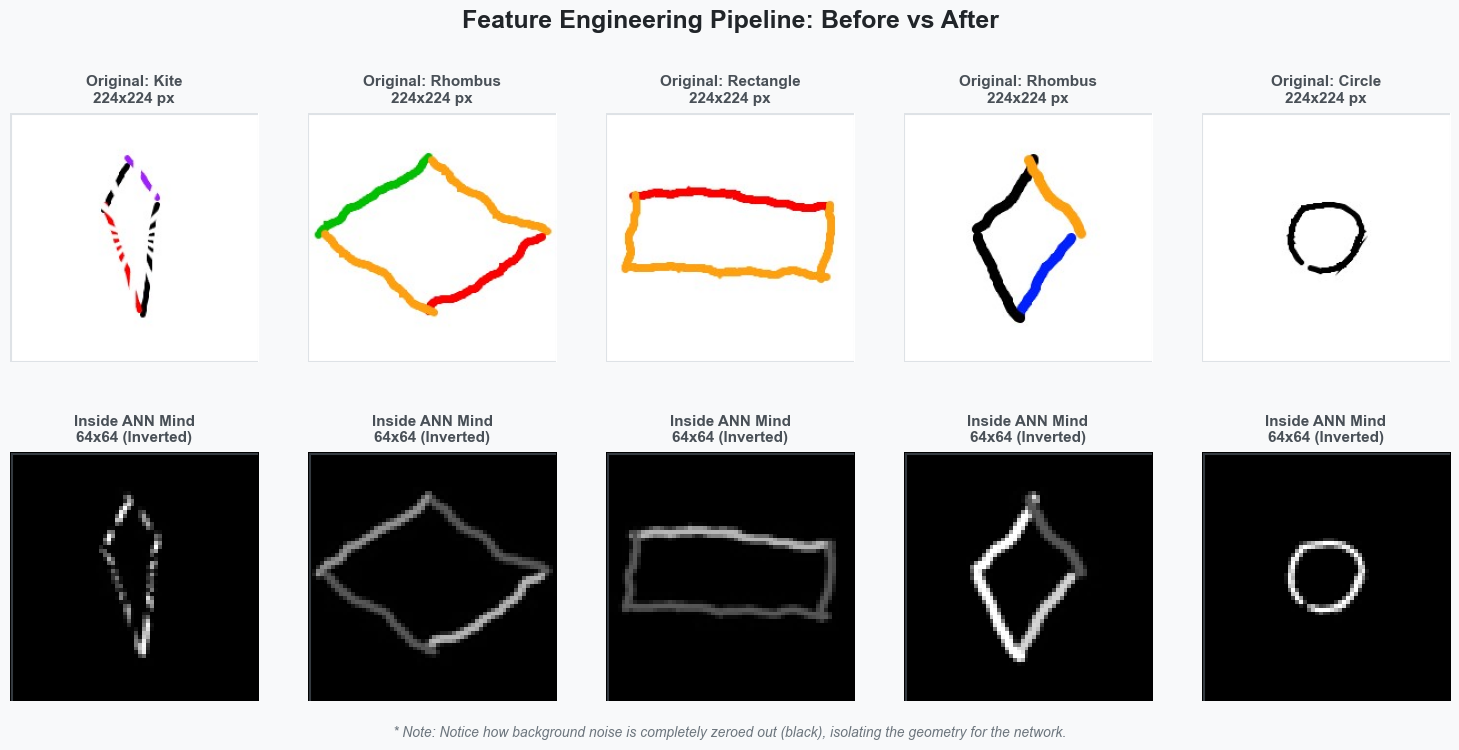

In [4]:
def visualize_feature_engineering_beautiful(csv_file='Database/shapes.csv', num_images=5):
    if not os.path.exists(csv_file):
        print(f"❌ שגיאה: לא נמצא קובץ בשם {csv_file}")
        return
        
    df = pd.read_csv(csv_file)
    random_rows = df.sample(n=num_images).to_dict(orient='records')
    
    sns.set_theme(style="white") 
    
    fig, axes = plt.subplots(2, num_images, figsize=(16, 7.5), facecolor='#f8f9fa')
    fig.suptitle('Feature Engineering Pipeline: Before vs After', fontsize=18, fontweight='bold', color='#212529', y=0.98)
    
    for i, row in enumerate(random_rows):
        img_path = row['filepaths']
        label = row['labels'].capitalize() 
        
        try:
            img_original = Image.open(img_path)
        except Exception:
            print(f"⚠️ לא מצליח לפתוח את התמונה: {img_path}")
            continue
            
        axes[0, i].imshow(img_original)
        axes[0, i].set_title(f"Original: {label}\n{img_original.size[0]}x{img_original.size[1]} px", 
                             fontsize=11, fontweight='semibold', color='#495057', pad=8)
        axes[0, i].axis('off')

        rect = plt.Rectangle((0,0), img_original.size[0], img_original.size[1], fill=False, color='#dee2e6', linewidth=1.5)
        axes[0, i].add_patch(rect)
        
        
        flat_features = process_single_image_features_grayscale_example(img_original, img_size=64)
        processed_img_2d = flat_features.reshape(64, 64).cpu().numpy()
        
        # הצגה עם מפת צבעים מנוגדת ונקייה (רקע שחור, קווים לבנים)
        axes[1, i].imshow(processed_img_2d, cmap='gray', vmin=0.0, vmax=1.0)
        axes[1, i].set_title("Inside ANN Mind\n64x64 (Inverted)", 
                             fontsize=11, fontweight='semibold', color='#495057', pad=8)
        axes[1, i].axis('off')
        
        rect_proc = plt.Rectangle((0,0), 64, 64, fill=False, color='#343a40', linewidth=1.5)
        axes[1, i].add_patch(rect_proc)
        
    plt.subplots_adjust(top=0.85, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.2)
    
    fig.text(0.5, 0.01, "* Note: Notice how background noise is completely zeroed out (black), isolating the geometry for the network.", 
             ha='center', fontsize=10, color='#6c757d', style='italic')
             
    plt.show()

visualize_feature_engineering_beautiful(csv_file='Database/shapes.csv', num_images=5)

<h3> Our Algorithm </h3>

<p>The Algorithm we are using in order to study our problem is called <b>ANN (Artificial Neural Network)</b>. It is build as a fully connected graph which consists of Input layer, hidden layers, and output layer.Each connection between the nodes has a numerical value assigned to it, known as <b> Weight</b>, and each neuron has an additional offset value called a <b> Bias </b>. The purpose of the network is to recieive a flattened input vector and by preforming mathematical equations within each node, calculates the probability of the image belonging to each of our exisiting classes.</p>

<p> For example, let's take a picture of a square. After processing it through our feature engineering pipeline, we flatten the image into a one-dimensional vector and feed it into our neural network. In the end, we inspect the output layer, which contains neurons representing our 8 target classes, and look for the one with the highest value. If the "square" neuron yields a value of 0.75 (the highest among all classes), our algorithm will predict that the image is indeed a square</p>

<p> We will explain in depth how it works while looking at each level of the Algorithm. </p>

<h3> Hyperparameters </h3>

<p>In this section, we will review the hyperparameters that control our model's architecture and training process. Adjusting these values allows us to optimize performance and fine-tune the network's behavior:</p>

<ul>
    <li><b>Image Size</b> - Determines the target resolution to which all input images are resized. We set our default to 64x64 pixels to balance feature detail with computational efficiency.</li>
    <li><b>Hidden Sizes</b> - Defines the number of neurons in each hidden layer. To encourage efficient feature extraction and dimensionality reduction, we structured them in a decreasing order: (256, 128, 64).</li>
    <li><b>Dropout Rate</b> - Specifies the percentage of randomly deactivated neurons during each forward pass. This prevents the network from over-relying on specific nodes, thereby reducing overfitting and forcing the model to learn more robust features.</li>
    <li><b>Learning Rate (lr)</b> - Controls the step size taken during gradient updates. A learning rate that is too high can cause the model to overshoot the optimal weights and diverge, while a rate that is too low can stunt the model's progress, requiring excessive time to converge.</li>
    <li><b>Momentum (Beta)</b> - Helps the model accelerate along the gradient descent path and prevents it from getting stuck in shallow, suboptimal local minimal (ensuring a more effective search for the best Weight and Bias values).</li>
    <li><b>Batch Size</b> - Dictates the number of images the model processes and analyzes together before performing a single gradient update step.</li>
    <li><b>Epochs</b> - Sets the total number of times the model will completely cycle through and study the entire training dataset.</li>
</ul>

<h3>Grid Search Optimization</h3>

<p>It is important to note that we have incorporated an optional <b>Grid Search</b> mechanism into our train function for automated hyperparameter tuning. By enabling this configuration (setting the feature flag to <code>True</code>), the model systematically iterates through a predefined multi-dimensional grid of hyperparameter combinations.</p>

<p>The training architecture automatically tracks and compares the evaluation metrics for every single permutation, ultimately selecting and exporting the optimal model state, defined as the configuration that achieves the highest validation <b>Accuracy</b> and the lowest overall <b>Loss</b>.</p>

In [5]:
CSV_FILE = "Database/shapes.csv"     
IMG_SIZE = 64             
INPUT_DIM = IMG_SIZE * IMG_SIZE
HIDDEN_SIZES = (256, 128, 64)
ELU_ALPHA = 1.0            

# ---------------------------------------------------------------------------
# REGULARIZATION (techniques that fight overfitting / memorization)
# ---------------------------------------------------------------------------
DROPOUT_P1 = 0.4            
DROPOUT_P2 = 0.3            
WEIGHT_DECAY = 1e-5

# ---------------------------------------------------------------------------
# OPTIMIZATION (how the weights are actually updated)
# ---------------------------------------------------------------------------
EPOCHS = 35                 
BATCH_SIZE = 128            
LEARNING_RATE = 0.002       
MOMENTUM_BETA = 0.9         

LR_DECAY_EVERY = 10
LR_DECAY_FACTOR = 0.6

# ---------------------------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------------------------
TRAINING_CURVE_PNG = "training_curves.png"
CONFUSION_MATRIX_PNG = "confusion_matrix.png"

# ---------------------------------------------------------------------------
# DEVICE (use the GPU automatically if one is available - just faster math)
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# GRID SEARCH (sweep hyperparameters automatically)
# ---------------------------------------------------------------------------
USE_GRID_SEARCH = False

GRID_SEARCH_PARAMS = {

    "LEARNING_RATE": [0.001, 0.005],
    "DROPOUT_P1":    [0.3, 0.5],
    "WEIGHT_DECAY":  [1e-5, 1e-4],
    "BATCH_SIZE":     [64, 128],
    "MOMENTUM_BETA":  [0.85, 0.9, 0.95],
    "DROPOUT_P2":     [0.2, 0.3, 0.4],
}


<h3> The Algorithm itself </h3>

<p>We will move with each function slowly in order to explain what each function does</p>

<p>The flow of the learning will look like this:</p>

```
Input  (Picture , 1, 64, 64)
  │
  ▼  Flatten → (Picture, 4096)
  │
  ▼  Linear(4,096 → 256) → ReLU → Dropout_P1
  ▼  Linear(256   → 128) → ReLU → Dropout_P2
  ▼  Linear(128   → 64) → ReLU
  ▼  Linear(64  →   8) → Softmax
```

<p>Going forward and backwards Depending on what we are doing</p>



In [6]:
def process_single_image_features_grayscale(img, img_size):
    img = img.convert("RGB").resize((img_size, img_size))

    img_gray = img.convert("L")


    img_inverted = PIL.ImageOps.invert(img_gray)


    img_tensor = torch.tensor(list(img_inverted.getdata()), dtype=torch.float32)

    normalized = img_tensor / 255.0
    return normalized


class GrayscaleShapesDataset(Dataset):
    def __init__(self, dataframe, img_size, name=""):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size

        features, labels = [], []
        print(f"[data] Loading + inverting '{name}' split "
              f"({len(self.df)} images)...")

        for idx in range(len(self.df)):
            img_path = self.df.iloc[idx]["filepaths"]
            label = self.df.iloc[idx]["label_idx"]
            try:
                with Image.open(img_path) as img:
                    feat = process_single_image_features_grayscale(img, img_size)
                features.append(feat)
                labels.append(torch.tensor(label, dtype=torch.long))
            except Exception:
                # Skip unreadable / corrupt files instead of crashing.
                continue

        self.all_features = torch.stack(features)
        self.all_labels = torch.stack(labels)
        print(f"[data] --> '{name}' ready. Background cleaned to zero.")

    def __len__(self):
        return len(self.all_features)

    def __getitem__(self, idx):
        return self.all_features[idx], self.all_labels[idx]

<p>Then, we will initialize all of our hyperparameters and assign random starting values to every trainable parameter in the network. Specifically, the <b>Weights</b> are initialized using a smart random distribution called <b>He Initialization</b> (Kaiming Normal), which scales the weights based on the layer's size. The <b>Biases</b> are initialized to the value of 0. This establishes our baseline, giving the model a starting point.</p>

In [7]:
class ManualGrayscaleANN:
    # -----------------------------------------------------------------
    # 1) INITIALIZATION  -  create the learnable parameters
    # -----------------------------------------------------------------
    def __init__(self, num_classes, input_dim, hidden_sizes,
                 dropout_p1=0.4, dropout_p2=0.3):
        h1, h2, h3 = hidden_sizes
        self.p1 = dropout_p1
        self.p2 = dropout_p2


        def he(fan_in, fan_out):
            return torch.randn(fan_in, fan_out) * torch.sqrt(
                torch.tensor(2.0 / fan_in))


        self.W1, self.b1 = he(input_dim, h1), torch.zeros(h1)
        self.W2, self.b2 = he(h1, h2),        torch.zeros(h2)
        self.W3, self.b3 = he(h2, h3),        torch.zeros(h3)
        self.W4, self.b4 = he(h3, num_classes), torch.zeros(num_classes)


        self.vW1, self.vb1 = torch.zeros_like(self.W1), torch.zeros_like(self.b1)
        self.vW2, self.vb2 = torch.zeros_like(self.W2), torch.zeros_like(self.b2)
        self.vW3, self.vb3 = torch.zeros_like(self.W3), torch.zeros_like(self.b3)
        self.vW4, self.vb4 = torch.zeros_like(self.W4), torch.zeros_like(self.b4)

    def to(self, device):
        """Move every tensor (parameters + momentum) onto CPU/GPU."""
        for attr in ["W1", "b1", "W2", "b2", "W3", "b3", "W4", "b4",
                     "vW1", "vb1", "vW2", "vb2", "vW3", "vb3", "vW4", "vb4"]:
            setattr(self, attr, getattr(self, attr).to(device))
        return self


<p>Then, we utilize our <b>forward</b> function to propagate the data through the neural network. This is achieved by computing the value of each node using the following mathematical linear combination:</p>

<p align="center"><i>Node Value = &sum; (Connected Node Value &times; Weight) + Bias</i></p>

<p>While passing through Hidden Layers 1 and 2, a predefined percentage of random neurons is dynamically deactivated (dropped) using the <b>Dropout</b> mechanism to prevent overfitting.</p>

<p>Immediately after each linear calculation in the hidden layers, we apply the <b>ReLU (Rectified Linear Unit)</b> activation function to handle non-linearity, which is defined as:</p>

<p align="center"><i>ReLU(Z) = max(0, Z)</i></p>

<p>Finally, at the output layer, a <b>Softmax</b> function is applied to the raw scores of the 8 classes. This function normalizes the outputs into a perfect probability distribution where the sum of all classes equals 1 (100%), allowing the algorithm to pick the shape with the highest percentage as its final guess.</p>

<p><b>Note</b>: The dropout will only happen on the training set. On prediction and test we will keep it off

In [8]:
def forward(self, x, is_training=True):
    self.x = x.reshape(x.size(0), -1)

    def relu(z):
        return torch.where(z > 0, z, torch.zeros_like(z))

    # --- Layer 1: linear -> ReLU -> dropout ---
    self.z1 = torch.matmul(self.x, self.W1) + self.b1
    self.a1 = relu(self.z1)
    if is_training:
        self.mask1 = (torch.rand_like(self.a1) >= self.p1).float()
        self.a1 = (self.a1 * self.mask1) / (1.0 - self.p1)

    # --- Layer 2: linear -> ReLU -> dropout ---
    self.z2 = torch.matmul(self.a1, self.W2) + self.b2
    self.a2 = relu(self.z2)
    if is_training:
        self.mask2 = (torch.rand_like(self.a2) >= self.p2).float()
        self.a2 = (self.a2 * self.mask2) / (1.0 - self.p2)

    # --- Layer 3: linear -> ReLU (no dropout) ---
    self.z3 = torch.matmul(self.a2, self.W3) + self.b3
    self.a3 = relu(self.z3)

    # --- Layer 4: linear -> Softmax (the output layer) ---
    self.logits = torch.matmul(self.a3, self.W4) + self.b4
    exp_logits = torch.exp(
        self.logits - torch.max(self.logits, dim=1, keepdim=True).values)
    self.probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    return torch.clamp(self.probs, min=1e-15, max=1.0)

ManualGrayscaleANN.forward = forward
del forward 


<p> After moving as such we will look at the percentage of the coresponding label and calculate it's loss in order for us to move accordingly in Backward Propogation. The error is computed using the <b>Categorical Cross-Entropy Loss</b> function, which is defined as:</p>

<p align="center"><i>Loss = -ln(P<sub>correct</sub>)</i></p>

<p>Where <i>P<sub>correct</sub></i> represents the probability that the model assigned to the true geometric class. To implement this robustly in code, two critical adjustments are made:</p>
<ul>

<li><b>Numerical Stability:</b> We add a tiny positive value  to prevent the mathematical impossibility of computing <i>ln(0)</i>, which would otherwise result in an undefined <code>NaN</code> or infinity error and crash the training loop.</li>

<li><b>One-Hot Encoding:</b> The true target label is represented as a <b>One-Hot Vector</b> (a matrix filled with 0s, where only the single index corresponding to the correct class is set to 1). This isolates the exact loss component for the true class. </li>


In [9]:
# =====================================================================
#  LOSS FUNCTION
# =====================================================================
def cross_entropy_loss(probs, labels_one_hot):
    n = labels_one_hot.size(0)
    return -torch.sum(labels_one_hot * torch.log(probs + 1e-15)) / n

<p>After calculating the <b>Loss</b>, we initiate the <b>Backward</b> function. In it we propagate the error backwards from the output layer toward the input layer, computing the gradients for every Weight and Bias based on the chain rule of calculus. The core calculations and mechanisms function as follows:</p>

<ul>
    <li><b>Weight Values:</b> - Calculated by multiplying the incoming error gradient (delta) by the activated neuron values from the corresponding forward pass, combined with the <b>Weight Decay</b> penalty.</li>
    <li><b>Bias Values</b> - Computed by summing the error gradients (deltas) across all samples in the current batch for that specific layer, isolating how much the bias offset contributed to the overall error.</li>
    <li><b>Derivative of ReLU:</b> It is critical to note that we do not apply the ReLU function itself during the backward pass; instead, we multiply by its derivative. This ensures that gradients only flow back through neurons that were active (greater than 0) during the forward pass.</li>
    <li><b>Dropout Mask Consistency</b> - To ensure mathematical consistency, the exact same neurons who were deactivated on the fowards function are turned down here too. This guarantees that deactivated neurons do not receive updates or pass  backward.</li>
    <li><b>Weight Decay</b> - A weight decay variable is incorporated into the weight update step. By adding a small penalty proportional to the magnitude of the weights, it prevents them from growing excessively large. This restrains the model from memorizing the training data, effectively resolving the overfitting issue.</li>
</ul>

In [10]:
def backward(self, labels_one_hot, lr, beta, weight_decay):
    N = labels_one_hot.size(0)

    def relu_deriv(z):
        return torch.where(z > 0, torch.ones_like(z), torch.zeros_like(z))

    # --- Output layer (4) ---
    delta4 = (self.probs - labels_one_hot) / N
    dW4 = torch.matmul(self.a3.t(), delta4)
    db4 = torch.sum(delta4, dim=0)

    # --- Hidden layer 3 ---
    dz3 = torch.matmul(delta4, self.W4.t()) * relu_deriv(self.z3)
    dW3 = torch.matmul(self.a2.t(), dz3)
    db3 = torch.sum(dz3, dim=0)

    # --- Hidden layer 2 ---
    da2 = torch.matmul(dz3, self.W3.t())
    if hasattr(self, "mask2"):
        da2 = (da2 * self.mask2) / (1.0 - self.p2)
    dz2 = da2 * relu_deriv(self.z2)
    dW2 = torch.matmul(self.a1.t(), dz2)
    db2 = torch.sum(dz2, dim=0)

    # --- Hidden layer 1 ---
    da1 = torch.matmul(dz2, self.W2.t())
    if hasattr(self, "mask1"):
        da1 = (da1 * self.mask1) / (1.0 - self.p1)
    dz1 = da1 * relu_deriv(self.z1)
    dW1 = torch.matmul(self.x.t(), dz1)
    db1 = torch.sum(dz1, dim=0)

    # --- Weight decay (L2 regularization) ---
    dW4 += weight_decay * self.W4
    dW3 += weight_decay * self.W3
    dW2 += weight_decay * self.W2
    dW1 += weight_decay * self.W1

    # --- Momentum SGD update ---
    for param, grad, vel_name in [
        (self.W4, dW4, "vW4"), (self.b4, db4, "vb4"),
        (self.W3, dW3, "vW3"), (self.b3, db3, "vb3"),
        (self.W2, dW2, "vW2"), (self.b2, db2, "vb2"),
        (self.W1, dW1, "vW1"), (self.b1, db1, "vb1"),
    ]:
        v_new = beta * getattr(self, vel_name) + grad
        setattr(self, vel_name, v_new)
        param -= lr * v_new

ManualGrayscaleANN.backward = backward
del backward  


<p> Before running our training function we will load a couple of functions in order to get our data during the training and use it later for calculating how well our model oprates</p>

<li><b> Evalute dataset </b> - We calculate our Avarage loss and Accuracy percent in order to display it during the training and have this data in order to build our confusion matrix </li>
<li><b> Build confusion Matrix</b> - Recives the parameters from the evaluation and creates a matrix out of them</li>
<li><b> Classification Report</b> - Calculates the Precsion, the Recall and the F1 score for each of our 8 classes using our confusion matrix, Those paremeters are calculated as the following equations:</li>

<p align="center"><i>Precision = TP / (TP + FP)</i></p>

<p align="center"><i>Recall = TP / (TP + FN)</i></p>

<p align="center"><i>F1-Score = 2 &times; (Precision &times; Recall) / (Precision + Recall)</i></p>

<p> where TP is True Positive, FP is False Positive and FN is False Negative</p>

<li><b>Plot Confusion Matrix</b> - A function that displays our confusion matrix as a heatmap graph where blue coresponds to higher values and white coresponds lower</li>

In [11]:
def evaluate_dataset(model, loader, num_classes, device):
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch_features, batch_labels in loader:
        X = batch_features.to(device, non_blocking=True)
        y = batch_labels.to(device, non_blocking=True)

        y_oh = torch.zeros(y.size(0), num_classes, device=device)
        y_oh.scatter_(1, y.long().view(-1, 1), 1.0)

        # is_training=False -> dropout disabled, full network used.
        probs = model.forward(X, is_training=False)
        loss = cross_entropy_loss(probs, y_oh)

        preds = torch.argmax(probs, dim=1)
        correct += torch.sum(preds == y).item()
        total += y.size(0)
        total_loss += loss.item() * y.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss / total, (correct / total) * 100.0, all_preds, all_labels


def build_confusion_matrix(preds, labels, num_classes):
    """Return an integer matrix M where M[true, predicted] = count."""
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(labels.tolist(), preds.tolist()):
        cm[t, p] += 1
    return cm


def classification_report(cm, class_names):
    cm = cm.float()
    num_classes = cm.size(0)

    tp = torch.diag(cm)                    # correct predictions per class
    fp = cm.sum(dim=0) - tp                # predicted C but wasn't C
    fn = cm.sum(dim=1) - tp                # was C but predicted otherwise
    support = cm.sum(dim=1)                # number of true samples per class

    precision = tp / (tp + fp + 1e-15)
    recall = tp / (tp + fn + 1e-15)
    f1 = 2 * precision * recall / (precision + recall + 1e-15)

    print("\n" + "=" * 70)
    print("PER-CLASS REPORT  (precision / recall / F1)")
    print("=" * 70)
    print(f"{'shape':<16}{'precision':>11}{'recall':>10}"
          f"{'f1':>9}{'support':>10}")
    print("-" * 70)
    for i in range(num_classes):
        print(f"{class_names[i]:<16}{precision[i]:>11.3f}{recall[i]:>10.3f}"
              f"{f1[i]:>9.3f}{int(support[i]):>10}")

    total = support.sum()
    macro_f1 = f1.mean().item()
    weighted_f1 = (f1 * support / total).sum().item()
    overall_acc = (tp.sum() / total).item() * 100.0

    print("-" * 70)
    print(f"{'macro avg F1':<16}{macro_f1:>30.3f}")
    print(f"{'weighted avg F1':<16}{weighted_f1:>30.3f}")
    print(f"{'overall accuracy':<16}{overall_acc:>29.2f}%")
    print("=" * 70)

    return {"precision": precision, "recall": recall, "f1": f1,
            "macro_f1": macro_f1, "weighted_f1": weighted_f1}


def plot_confusion_matrix(cm, class_names, out_path):
    cm_np = cm.numpy()
    fig, ax = plt.subplots(figsize=(1.4 * len(class_names) + 3,
                                    1.4 * len(class_names) + 3))
    im = ax.imshow(cm_np, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix", fontweight="bold")

    thresh = cm_np.max() / 2.0 if cm_np.max() > 0 else 0.5
    for i in range(cm_np.shape[0]):
        for j in range(cm_np.shape[1]):
            ax.text(j, i, str(cm_np[i, j]), ha="center", va="center",
                    color="white" if cm_np[i, j] > thresh else "black")

    fig.tight_layout()
    plt.show()
    plt.close(fig)


<p>Now, we move to our core <b>Training</b> function, which orchestrates and integrates all the individual functions described above. The training execution runs sequentially for a predefined number of epochs, where each epoch follows a structured cycle:</p>

<ul>
    <li><b>Batch-by-Batch Execution:</b> In each epoch, the training dataset is partitioned into smaller, shuffled batches. For every single batch, the model executes the <b>Forward Function</b>, calculates the <b>Loss</b>, and performs <b>Backward Function</b> to continuously adjust the parameters (Weights and Biases).</li>
    <li><b>Performance Evaluation:</b> Once a full epoch is completed (meaning the model has cycled through the entire training set), the network evaluates its overall performance on both the training and validation sets, displaying metrics such as current Loss and Accuracy.</li>
    <li><b>Tracking the Best Model State:</b> To ensure optimal results and prevent overfitting, the training loop monitors the validation metrics and keeps a copy of the model from the most optimal epoch (the state where the model achieved the lowest validation loss).</li>
    <li><b>Learning Rate Schedule (Decay):</b> It is important to note that the learning rate is systematically decreased every couple of epochs. This learning rate decay allows the model to take smaller, more precise adjustment steps as it approaches convergence, avoiding overshooting the optimal global minimum.</li>
    <li><b>Progress Visualization:</b> Finally, the entire training trajectory is saved and plotted as a loss and accuracy graph, providing a clear visual representation of the model's learning journey and stability.</li>
</ul>

In [12]:
def _one_hot(y, num_classes, device):
    oh = torch.zeros(y.size(0), num_classes, device=device)
    oh.scatter_(1, y.long().view(-1, 1), 1.0)
    return oh


def train_model(model, loader_train, loader_valid, num_classes, cfg):
    lr = cfg.LEARNING_RATE
    best_valid_loss = float("inf")
    best_model = None

    history = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": []}

    print("\nTraining (manual forward + manual backprop)...")
    print("=" * 78)

    for epoch in range(cfg.EPOCHS):
        running_loss, correct, total = 0.0, 0, 0

        for batch_features, batch_labels in loader_train:
            X = batch_features.to(cfg.DEVICE, non_blocking=True)
            y = batch_labels.to(cfg.DEVICE, non_blocking=True)
            y_oh = _one_hot(y, num_classes, cfg.DEVICE)

            # 1) FORWARD
            probs = model.forward(X, is_training=True)

            # 2) LOSS
            loss = cross_entropy_loss(probs, y_oh)

            # 3) + 4) BACKWARD + UPDATE
            model.backward(y_oh, lr=lr, beta=cfg.MOMENTUM_BETA,
                           weight_decay=cfg.WEIGHT_DECAY)

            running_loss += loss.item() * y.size(0)
            correct += torch.sum(torch.argmax(probs, dim=1) == y).item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = (correct / total) * 100.0

        # --- Validation check (NOT used to update weights) ---
        val_loss, val_acc, _, _ = evaluate_dataset(
            model, loader_valid, num_classes, cfg.DEVICE)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch + 1:02d}/{cfg.EPOCHS:02d}]  "
              f"Train Loss {train_loss:.4f} | Train Acc {train_acc:5.2f}%  ||  "
              f"Val Loss {val_loss:.4f} | Val Acc {val_acc:5.2f}%")

        if val_loss < best_valid_loss:
            best_valid_loss = val_loss
            best_model = copy.deepcopy(model)
            print("   --> [checkpoint] new best validation weights saved")

        if (epoch + 1) % cfg.LR_DECAY_EVERY == 0:
            lr *= cfg.LR_DECAY_FACTOR
            print(f"   --> [lr decay] learning rate is now {lr:.5f}")

    print("=" * 78)
    print("Training finished.")
    return best_model, history


def plot_training_curves(history, out_path):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

    ax_loss.plot(epochs, history["train_loss"], "o-", label="Train Loss")
    ax_loss.plot(epochs, history["val_loss"], "s-", label="Validation Loss")
    ax_loss.set_title("Loss per Epoch")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Cross-Entropy Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epochs, history["train_acc"], "o-", label="Train Accuracy")
    ax_acc.plot(epochs, history["val_acc"], "s-", label="Validation Accuracy")
    ax_acc.set_title("Accuracy per Epoch")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    fig.suptitle("ANN Training Progress", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


<p>This piece of code will run all the pictures through our feature engineering function and save all the solutions into the RAM </p>

In [13]:
cfg = type("cfg", (), {})()  # lightweight namespace from the Config cell
for _k in ["CSV_FILE","IMG_SIZE","INPUT_DIM","HIDDEN_SIZES",
           "DROPOUT_P1","DROPOUT_P2","WEIGHT_DECAY","EPOCHS","BATCH_SIZE",
           "LEARNING_RATE","MOMENTUM_BETA","LR_DECAY_EVERY","LR_DECAY_FACTOR",
           "TRAINING_CURVE_PNG","CONFUSION_MATRIX_PNG","DEVICE"]:
    setattr(cfg, _k, globals()[_k])

assert os.path.exists(cfg.CSV_FILE), f"'{cfg.CSV_FILE}' not found"

df = pd.read_csv(cfg.CSV_FILE)
class_names = sorted(df["labels"].unique())
df["label_idx"] = df["labels"].map({n: i for i, n in enumerate(class_names)})
num_classes = len(class_names)

train_df = df[df["data set"] == "train"].reset_index(drop=True)
valid_df = df[df["data set"] == "valid"].reset_index(drop=True)
test_df  = df[df["data set"] == "test"].reset_index(drop=True)

ds_train = GrayscaleShapesDataset(train_df, cfg.IMG_SIZE, name="Train")
ds_valid = GrayscaleShapesDataset(valid_df, cfg.IMG_SIZE, name="Validation")
ds_test  = GrayscaleShapesDataset(test_df,  cfg.IMG_SIZE, name="Test")

loader_train = DataLoader(ds_train, batch_size=cfg.BATCH_SIZE,
                          shuffle=True, drop_last=True)
loader_valid = DataLoader(ds_valid, batch_size=cfg.BATCH_SIZE, shuffle=False)
loader_test  = DataLoader(ds_test,  batch_size=cfg.BATCH_SIZE, shuffle=False)

model = ManualGrayscaleANN(
    num_classes=num_classes, input_dim=cfg.INPUT_DIM,
    hidden_sizes=cfg.HIDDEN_SIZES,
    dropout_p1=cfg.DROPOUT_P1, dropout_p2=cfg.DROPOUT_P2,
).to(cfg.DEVICE)

print(f"Device: {cfg.DEVICE}")
print(f"Architecture: {cfg.INPUT_DIM} -> "
      f"{' -> '.join(map(str, cfg.HIDDEN_SIZES))} -> {num_classes} (ReLU)")

state = {
    "cfg": cfg, "model": model, "num_classes": num_classes,
    "class_names": class_names,
    "test_df": test_df,
    "loader_train": loader_train, "loader_valid": loader_valid,
    "loader_test":  loader_test,
}


[data] Loading + inverting 'Train' split (12000 images)...


C:\Users\razi3\AppData\Local\Temp\ipykernel_32816\3743890839.py:10: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  img_tensor = torch.tensor(list(img_inverted.getdata()), dtype=torch.float32)


[data] --> 'Train' ready. Background cleaned to zero.
[data] Loading + inverting 'Validation' split (4000 images)...
[data] --> 'Validation' ready. Background cleaned to zero.
[data] Loading + inverting 'Test' split (4000 images)...
[data] --> 'Test' ready. Background cleaned to zero.
Device: cuda
Architecture: 4096 -> 256 -> 128 -> 64 -> 8 (ReLU)


<h3> Training Loop </h3>

<p>Now it's time to train our model and see our results!</p>


Training (manual forward + manual backprop)...
Epoch [01/35]  Train Loss 2.0608 | Train Acc 17.67%  ||  Val Loss 1.9468 | Val Acc 29.95%
   --> [checkpoint] new best validation weights saved
Epoch [02/35]  Train Loss 1.8974 | Train Acc 28.02%  ||  Val Loss 1.7422 | Val Acc 39.02%
   --> [checkpoint] new best validation weights saved
Epoch [03/35]  Train Loss 1.7048 | Train Acc 37.36%  ||  Val Loss 1.5176 | Val Acc 51.08%
   --> [checkpoint] new best validation weights saved
Epoch [04/35]  Train Loss 1.5208 | Train Acc 45.39%  ||  Val Loss 1.3189 | Val Acc 61.20%
   --> [checkpoint] new best validation weights saved
Epoch [05/35]  Train Loss 1.3700 | Train Acc 51.08%  ||  Val Loss 1.1485 | Val Acc 68.80%
   --> [checkpoint] new best validation weights saved
Epoch [06/35]  Train Loss 1.2113 | Train Acc 57.54%  ||  Val Loss 0.9864 | Val Acc 74.80%
   --> [checkpoint] new best validation weights saved
Epoch [07/35]  Train Loss 1.0840 | Train Acc 63.16%  ||  Val Loss 0.8553 | Val Acc 77.88

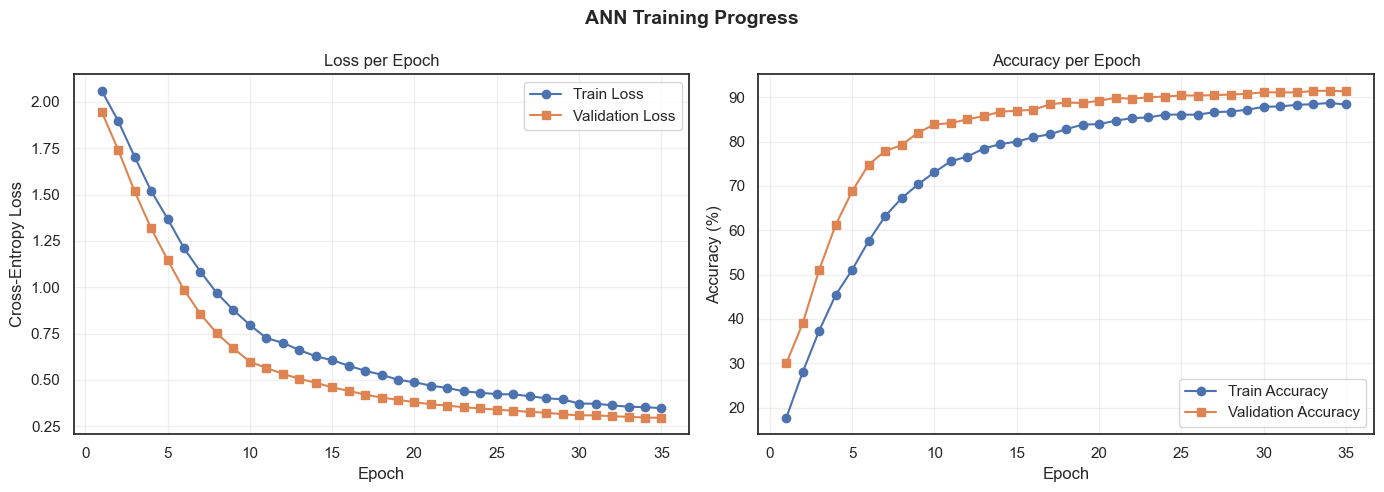

In [14]:
import copy
import itertools

# ---------------------------------------------------------------------------
# Helper: train ONE config and return the best validation loss + the model.
# ---------------------------------------------------------------------------
def _train_one(state, overrides=None):
    cfg = state["cfg"]
    overrides = overrides or {}

    snapshot = {k: getattr(cfg, k) for k in overrides}
    for k, v in overrides.items():
        setattr(cfg, k, v)

    loader_train = state["loader_train"]
    if "BATCH_SIZE" in overrides:
        loader_train = DataLoader(state["loader_train"].dataset,
                                  batch_size=cfg.BATCH_SIZE,
                                  shuffle=True, drop_last=True)

    fresh_model = ManualGrayscaleANN(
        num_classes=state["num_classes"], input_dim=cfg.INPUT_DIM,
        hidden_sizes=cfg.HIDDEN_SIZES,
        dropout_p1=cfg.DROPOUT_P1, dropout_p2=cfg.DROPOUT_P2,
    ).to(cfg.DEVICE)

    best_model, history = train_model(
        fresh_model, loader_train, state["loader_valid"],
        state["num_classes"], cfg)

    best_val_loss = min(history["val_loss"])
    best_val_acc  = max(history["val_acc"])

    # Restore cfg so the next combo starts from a clean slate.
    for k, v in snapshot.items():
        setattr(cfg, k, v)

    return {"model": best_model, "history": history,
            "val_loss": best_val_loss, "val_acc": best_val_acc,
            "overrides": dict(overrides)}


# ---------------------------------------------------------------------------
# Branch: single training run, OR grid search.
# ---------------------------------------------------------------------------
if not USE_GRID_SEARCH:
    # --- SINGLE RUN (original behavior) ------------------------------------
    result = _train_one(state, overrides=None)
    state["best_model"] = result["model"]
    state["history"]    = result["history"]
    state["best_combo"] = {}
    plot_training_curves(result["history"], state["cfg"].TRAINING_CURVE_PNG)

else:
    # --- GRID SEARCH -------------------------------------------------------
    param_names = list(GRID_SEARCH_PARAMS.keys())
    value_lists = [GRID_SEARCH_PARAMS[k] for k in param_names]
    combos = list(itertools.product(*value_lists))
    total = len(combos)
    print(f"[grid-search] testing {total} combinations across "
          f"{len(param_names)} hyperparameters: {param_names}")
    print("=" * 78)

    results = []
    for i, combo_values in enumerate(combos, start=1):
        overrides = dict(zip(param_names, combo_values))
        pretty = ", ".join(f"{k}={v}" for k, v in overrides.items())
        print(f"\n[grid-search] run {i}/{total}  ->  {pretty}")
        print("-" * 78)
        results.append(_train_one(state, overrides=overrides))

    # ----- Summary table, sorted by validation loss (lower = better) ------
    results.sort(key=lambda r: r["val_loss"])
    print("\n" + "=" * 78)
    print(f"[grid-search] FINAL RANKING (by best validation loss)")
    print("=" * 78)
    header = f"{'rank':>4}  {'val_loss':>9}  {'val_acc':>8}   params"
    print(header); print("-" * 78)
    for rank, r in enumerate(results, start=1):
        pretty = ", ".join(f"{k}={v}" for k, v in r["overrides"].items())
        marker = "  <-- best" if rank == 1 else ""
        print(f"{rank:>4}  {r['val_loss']:>9.4f}  {r['val_acc']:>7.2f}%   "
              f"{pretty}{marker}")
    print("=" * 78)

    # ----- Keep the winner for all downstream cells ------------------------
    winner = results[0]
    state["best_model"]   = winner["model"]
    state["history"]      = winner["history"]
    state["best_combo"]   = winner["overrides"]
    state["grid_results"] = results

    # Also write the winning values onto cfg so downstream code sees them.
    for k, v in winner["overrides"].items():
        setattr(state["cfg"], k, v)

    print(f"\n[grid-search] winning combo: {winner['overrides']}")
    print(f"[grid-search] winning val_loss={winner['val_loss']:.4f}, "
          f"val_acc={winner['val_acc']:.2f}%")
    plot_training_curves(winner["history"], state["cfg"].TRAINING_CURVE_PNG)


<h3> Prediction </h3>

<p>Now that we trained our model let's check our prediction to a random picture to see the model at work</p>

C:\Users\razi3\AppData\Local\Temp\ipykernel_32816\3743890839.py:10: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  img_tensor = torch.tensor(list(img_inverted.getdata()), dtype=torch.float32)


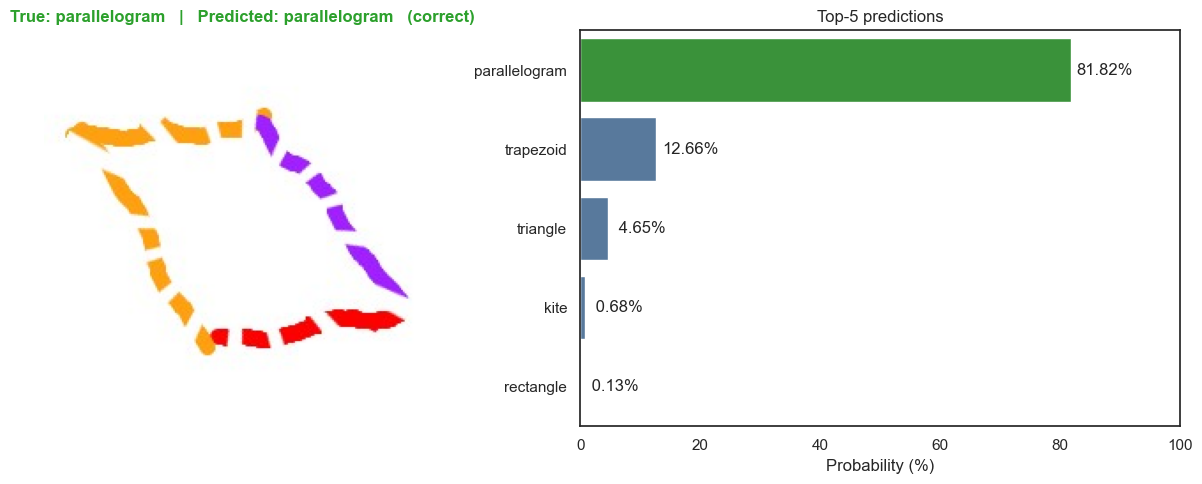

image: Database\test\parallelogram\parallelogram-2458.jpg
true class:      parallelogram
predicted class: parallelogram  (81.82% confidence)


In [15]:
assert "best_model" in state, "Run the training cell (Section 8) first."

SEED = None   # e.g. SEED = 42 for a fixed pick; None = random each run
TOP_K = 5

if SEED is not None:
    random.seed(SEED)

test_df = state["test_df"]
idx = random.randrange(len(test_df))
row = test_df.iloc[idx]
img_path  = row["filepaths"]
true_label = row["labels"]

# Run the SAME feature-engineering pipeline used in training.
with Image.open(img_path) as raw_img:
    raw_for_display = raw_img.convert("RGB").copy()
    feat = process_single_image_features_grayscale(raw_img, state["cfg"].IMG_SIZE)

# Forward pass on a batch of 1 (is_training=False -> dropout off).
x = feat.unsqueeze(0).to(state["cfg"].DEVICE)
probs = state["best_model"].forward(x, is_training=False)[0].detach().cpu()

# Top-K probabilities.
k = min(TOP_K, state["num_classes"])
top_probs, top_idx = torch.topk(probs, k=k)
top_probs = top_probs.numpy() * 100.0
top_names = [state["class_names"][i] for i in top_idx.tolist()]
pred_label = top_names[0]
is_correct = (pred_label == true_label)

# --- Plot side by side: image | top-K bar chart ------------------------
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                      gridspec_kw={"width_ratios": [1, 1.4]})

ax_img.imshow(raw_for_display)
ax_img.axis("off")
verdict = "correct" if is_correct else "wrong"
color   = "#2ca02c" if is_correct else "#d62728"
ax_img.set_title(f"True: {true_label}   |   Predicted: {pred_label}   ({verdict})",
                 color=color, fontweight="bold")

# Bar chart: most-likely class on top.
bar_colors = ["#2ca02c" if name == true_label else "#4c78a8" for name in top_names]
sns.barplot(x=top_probs, y=top_names, hue=top_names, palette=bar_colors, legend=False, ax=ax_bar)
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel("Probability (%)")
ax_bar.set_title(f"Top-{k} predictions")
for i, p in enumerate(top_probs):
    ax_bar.text(p + 1, i, f"{p:5.2f}%", va="center")

plt.tight_layout()
plt.show()

print(f"image: {img_path}")
print(f"true class:      {true_label}")
print(f"predicted class: {pred_label}  ({top_probs[0]:.2f}% confidence)")


<h3>Test Check / F1 Score </h3>

<p> As we can see it's predicts the picture most of the times, Now that we checked it on a single picture let's test it on all our test pictures and see the F1 score for each class</p>

<p><b>Importent Note</b> - In our training set we used a dropout function in order to have the model learn better. In the test and prediction we will turn that function off so our model can predict the values at his best form</p>

In [16]:
assert "best_model" in state, "Run the training cell (Section 8) first."

test_loss, test_acc, preds, labels = evaluate_dataset(
    state["best_model"], state["loader_test"],
    state["num_classes"], state["cfg"].DEVICE)
print(f"FINAL TEST ACCURACY: {test_acc:.2f}%   (Loss: {test_loss:.4f})")

cm = build_confusion_matrix(preds, labels, state["num_classes"])
classification_report(cm, state["class_names"])

# Cache for the confusion-matrix cell below.
state["test_loss"]   = test_loss
state["test_acc"]    = test_acc
state["test_preds"]  = preds
state["test_labels"] = labels
state["test_cm"]     = cm

FINAL TEST ACCURACY: 91.17%   (Loss: 0.2929)

PER-CLASS REPORT  (precision / recall / F1)
shape             precision    recall       f1   support
----------------------------------------------------------------------
circle                0.954     0.956    0.955       500
kite                  0.933     0.940    0.936       500
parallelogram         0.840     0.832    0.836       500
rectangle             0.955     0.972    0.963       500
rhombus               0.963     0.996    0.979       500
square                0.931     0.996    0.962       500
trapezoid             0.829     0.784    0.806       500
triangle              0.878     0.818    0.847       500
----------------------------------------------------------------------
macro avg F1                             0.911
weighted avg F1                          0.911
overall accuracy                        91.18%


<h3> Confusion Matrix</h3>

<p>As we can see our test accuracy stands at around 90%  which means that our model guesses right 1 out of 10 pictures and we can say it is much better then a random choice (Which is 12.5%), Now let's see this clearly on a heatmap</p>  

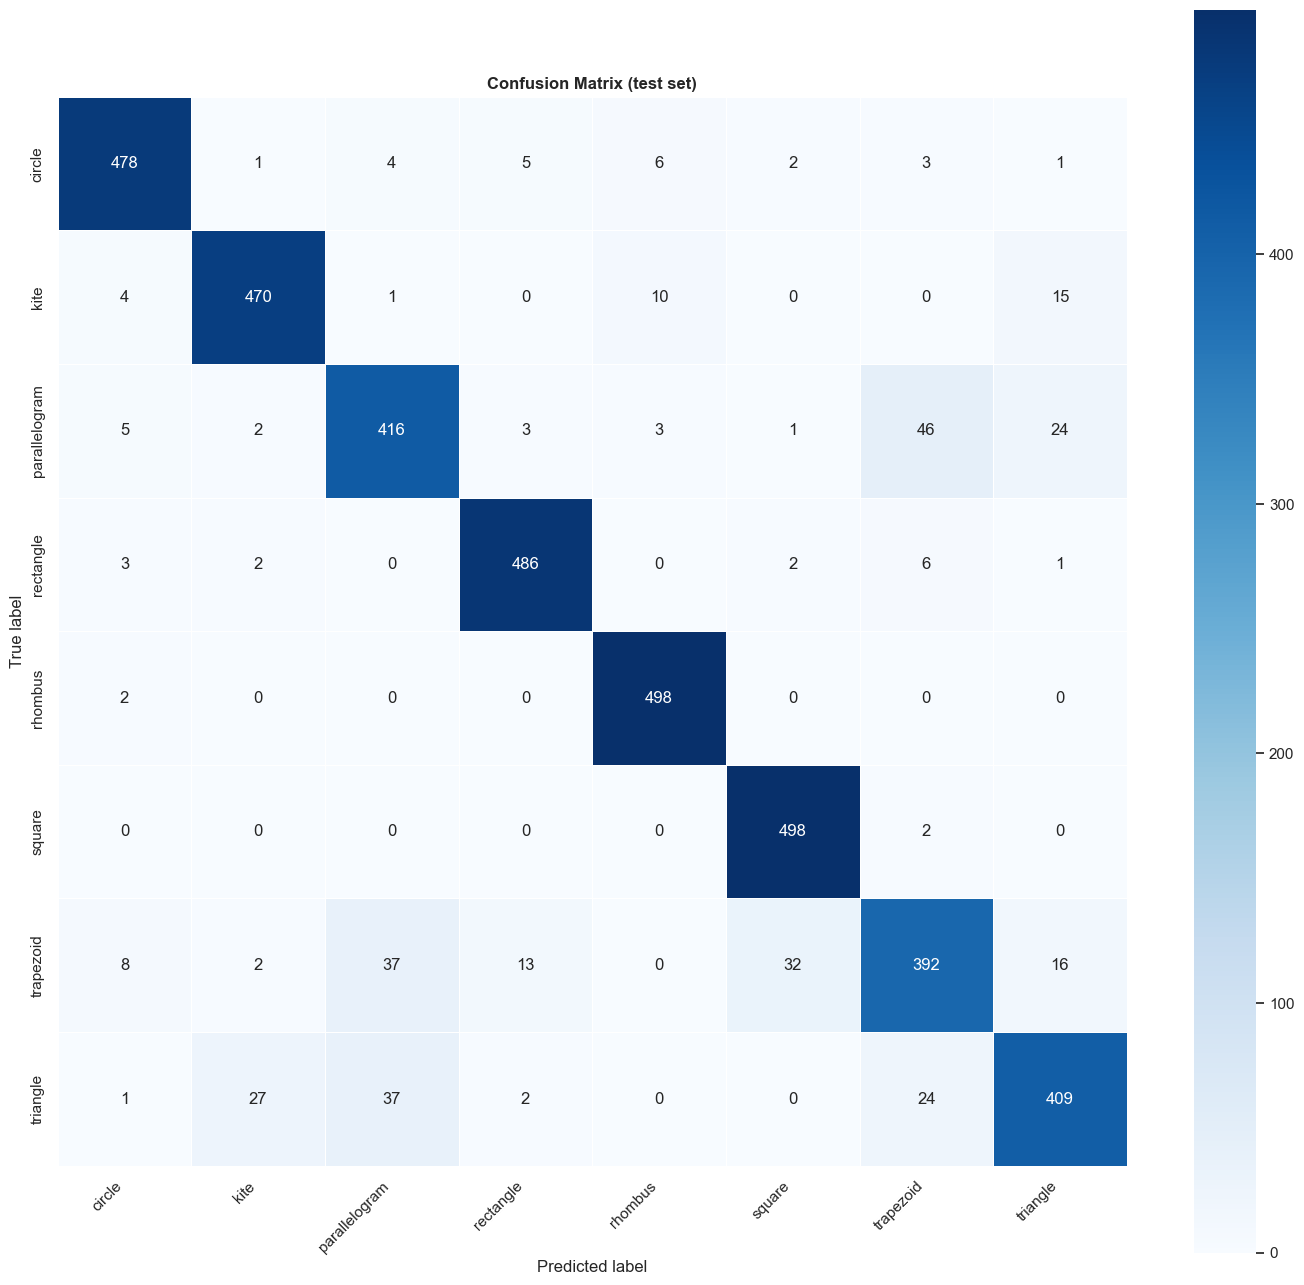

In [17]:
assert "test_cm" in state, "Run the F1 report cell (Section 9) first."

cm_np = state["test_cm"].numpy()
fig, ax = plt.subplots(figsize=(1.4 * len(state["class_names"]) + 3,
                                1.4 * len(state["class_names"]) + 2))
sns.heatmap(
    cm_np, annot=True, fmt="d", cmap="Blues", cbar=True,
    xticklabels=state["class_names"], yticklabels=state["class_names"],
    ax=ax, square=True, linewidths=0.5, linecolor="white",
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (test set)", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()
